In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

In [28]:
df = pd.read_csv(url)

print(df.head())
print(df.shape)
print(df.info())

     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121
(144, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Month       144 non-null    object
 1   Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB
None


In [29]:
df["Month"] = pd.to_datetime(df["Month"])

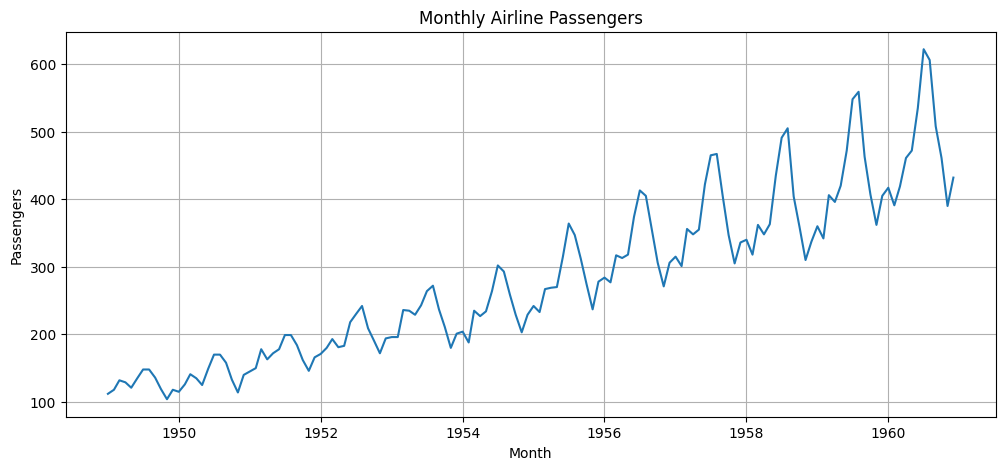

In [30]:
plt.figure(figsize=(12, 5))

plt.plot(df["Month"], df["Passengers"])

plt.title("Monthly Airline Passengers")
plt.xlabel("Month")
plt.ylabel("Passengers")

plt.grid()
plt.show()

In [31]:
data = df["Passengers"].values.astype("float32")
data = data.reshape(-1, 1)

In [32]:
split = int(len(data) * 0.8)

train_data = data[:split]
test_data = data[split:]

In [33]:
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

In [34]:
def create_sequences(data, lookback=12):
    X = []
    y = []

    for i in range(len(data) - lookback):
        X.append(data[i:i + lookback])
        y.append(data[i + lookback])

    return np.array(X), np.array(y)

In [35]:
X_train, y_train = create_sequences(train_scaled, 12)
X_test, y_test = create_sequences(test_scaled, 12)

In [36]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (103, 12, 1)
y_train: (103, 1)
X_test: (17, 12, 1)
y_test: (17, 1)


In [37]:
rnn_model = Sequential([
    SimpleRNN(50, activation="tanh", input_shape=(12, 1)),
    Dense(1)
])

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [38]:
rnn_model.compile(
    optimizer="adam",
    loss="mse"
)

In [39]:
rnn_history = rnn_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1
)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0810 - val_loss: 0.0213
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0209 - val_loss: 0.0252
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0092 - val_loss: 0.0263
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0054 - val_loss: 0.0040
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0048 - val_loss: 0.0031
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0025 - val_loss: 0.0062
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0032 - val_loss: 0.0036
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0025 - val_loss: 0.0017
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0020 - val_loss: 0.0019
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0019 - val_loss: 0.0023
Epoch 11/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0021 - val_loss: 0.0020
Epoch 12/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0017 - val_loss: 0.0013
Epoch 13/50

In [40]:
lstm_model = Sequential([
    LSTM(50, activation="tanh", input_shape=(12, 1)),
    Dense(1)
])

In [43]:
lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

lstm_history = lstm_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1
)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0824 - val_loss: 0.0979
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0277 - val_loss: 0.0204
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0131 - val_loss: 0.0403
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0152 - val_loss: 0.0205
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0098 - val_loss: 0.0225
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0106 - val_loss: 0.0209
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0091 - val_loss: 0.0218
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0103 - val_loss: 0.0257
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0089 - val_loss: 0.0227
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0090 - val_loss: 0.0223
Epoch 11/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0085 - val_loss: 0.0227
Epoch 12/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0068 - val_loss: 0.0256
Epoch 13/50

In [44]:
rnn_pred = rnn_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step


In [45]:
lstm_pred = lstm_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


In [46]:
rnn_pred_actual = scaler.inverse_transform(rnn_pred)
lstm_pred_actual = scaler.inverse_transform(lstm_pred)

y_test_actual = scaler.inverse_transform(y_test)

In [47]:
rnn_rmse = np.sqrt(
    mean_squared_error(y_test_actual, rnn_pred_actual)
)

lstm_rmse = np.sqrt(
    mean_squared_error(y_test_actual, lstm_pred_actual)
)

print("RNN RMSE:", rnn_rmse)
print("LSTM RMSE:", lstm_rmse)

RNN RMSE: 45.979439826065196
LSTM RMSE: 62.91625448264542


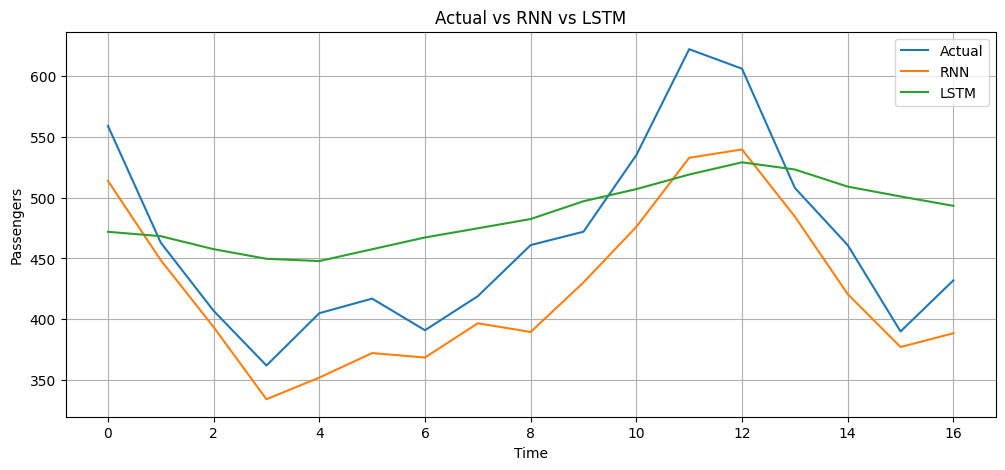

In [48]:
plt.figure(figsize=(12, 5))

plt.plot(y_test_actual, label="Actual")
plt.plot(rnn_pred_actual, label="RNN")
plt.plot(lstm_pred_actual, label="LSTM")

plt.title("Actual vs RNN vs LSTM")
plt.xlabel("Time")
plt.ylabel("Passengers")

plt.legend()
plt.grid()
plt.show()

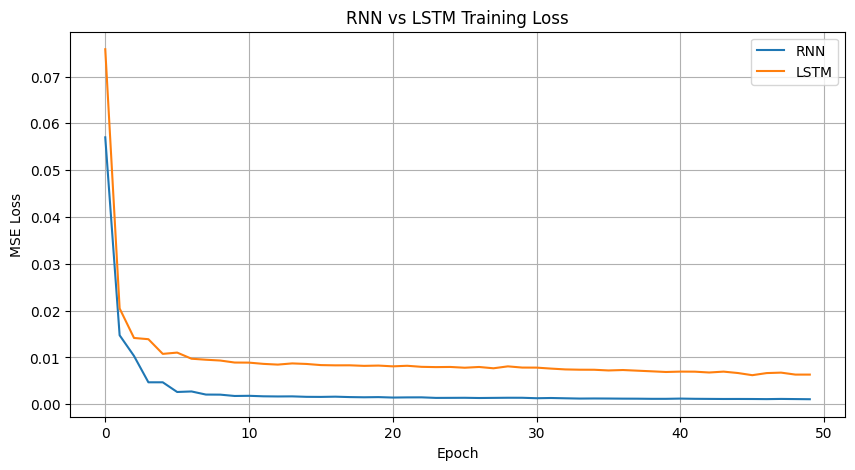

In [49]:
plt.figure(figsize=(10, 5))

plt.plot(
    rnn_history.history["loss"],
    label="RNN"
)

plt.plot(
    lstm_history.history["loss"],
    label="LSTM"
)

plt.title("RNN vs LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.legend()
plt.grid()
plt.show()

In [ ]:
model = lstm_model
sequence = test_scaled[-12:].reshape(1, 12, 1)
future = []

for i in range(12):

    prediction = model.predict(
        sequence,
        verbose=0
    )

    future.append(prediction[0, 0])

    sequence = np.append(
        sequence[:, 1:, :],
        prediction.reshape(1, 1, 1),
        axis=1
    )
future = scaler.inverse_transform(
    np.array(future).reshape(-1, 1)
)

NameError: name 'future' is not defined

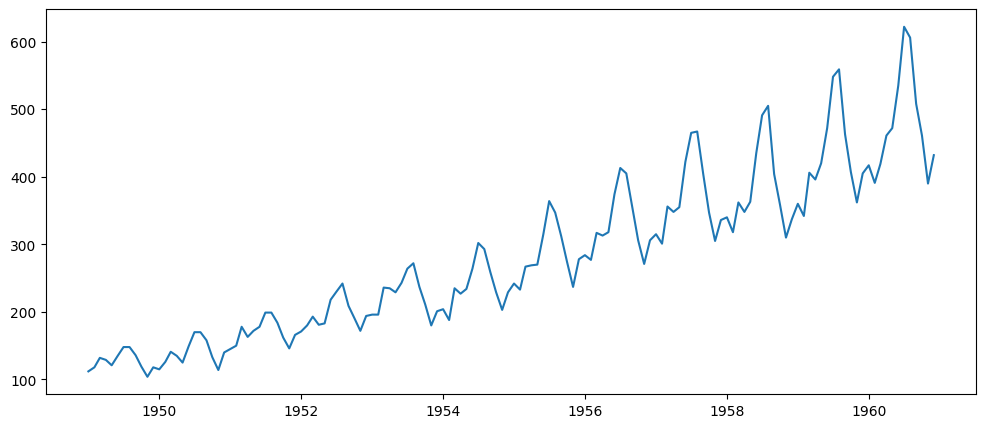

In [50]:
future_dates = pd.date_range(
    start=df["Month"].iloc[-1] + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)

plt.figure(figsize=(12, 5))

plt.plot(
    df["Month"],
    df["Passengers"],
    label="Historical"
)

plt.plot(
    future_dates,
    future,
    label="Future Forecast"
)

plt.title("Future Airline Passenger Forecast")
plt.xlabel("Month")
plt.ylabel("Passengers")

plt.legend()
plt.grid()
plt.show()